<h2><b>📌 INTRODUCTION</b></h2>

In [ ]:
# PROJECT: Customer Segmentation Using Unsupervised Learning

This project clusters mall customers based on their spending behavior using unsupervised learning.  
The goal is to identify customer segments that can help tailor marketing strategies effectively.

The dataset contains information like age, annual income, and spending score, which will be used to group similar customers.

# 🎯 Objectives:
- Load and preprocess the dataset  
- Conduct Exploratory Data Analysis (EDA)  
- Apply K-Means Clustering  
- Use PCA or t-SNE to visualize clusters  
- Suggest marketing strategies for each cluster

In [ ]:
# STEP 1: Basic libraries
# Basic Libraries

import pandas as pd
import numpy as np

In [4]:
# # STEP 2: Load the dataset
df = pd.read_excel('Mall_Customers.xlsx')

# Preview the first few rows
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [6]:
# STEP 3: Check for missing values and renaming table 
df.info()

# Rename columns for consistency
df.columns = ['CustomerID', 'Gender', 'Age', 'Education', 'Marital_Status', 'Annual_Income_k$', 'Spending_Score']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (k$)      200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB


<h2><b>Visualization</b></h2>

<h2><b>Pairplot</b></h2>

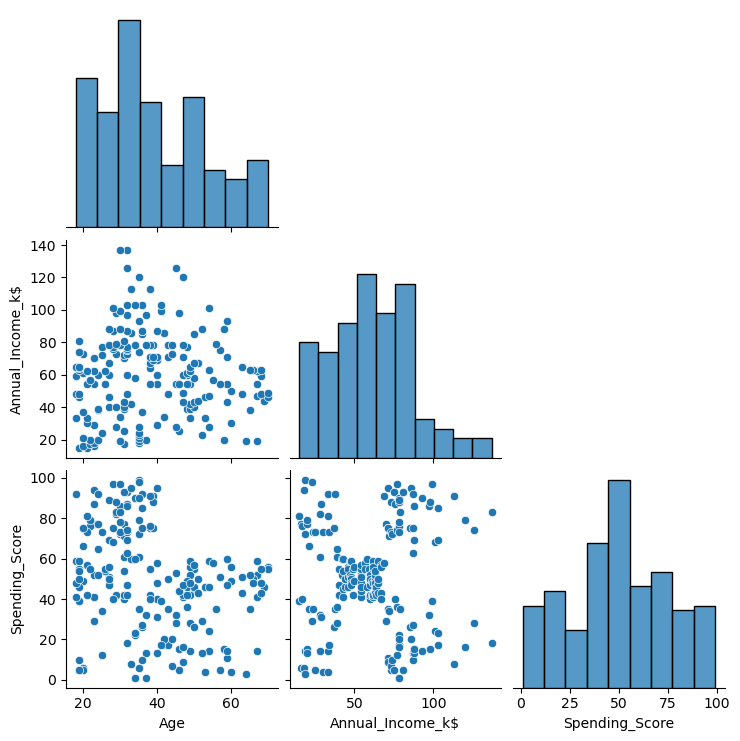

       CustomerID         Age  Annual_Income_k$  Spending_Score
count  200.000000  200.000000        200.000000      200.000000
mean   100.500000   38.850000         60.560000       50.200000
std     57.879185   13.969007         26.264721       25.823522
min      1.000000   18.000000         15.000000        1.000000
25%     50.750000   28.750000         41.500000       34.750000
50%    100.500000   36.000000         61.500000       50.000000
75%    150.250000   49.000000         78.000000       73.000000
max    200.000000   70.000000        137.000000       99.000000


In [11]:
# STEP 4: Exploratory Data Analysis Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Pairplot
sns.pairplot(df[['Age', 'Annual_Income_k$', 'Spending_Score']], corner=True)
plt.show()

print(df.describe())

<h2><b>Histogarm</b></h2>

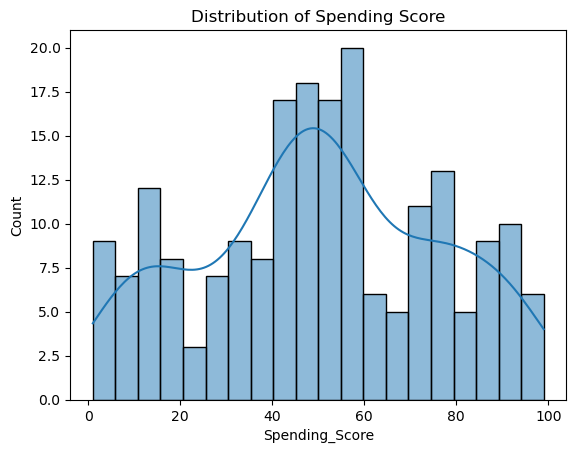

In [13]:
# Distribution of Spending Score
sns.histplot(df['Spending_Score'], kde=True, bins=20)
plt.title('Distribution of Spending Score')
plt.show()

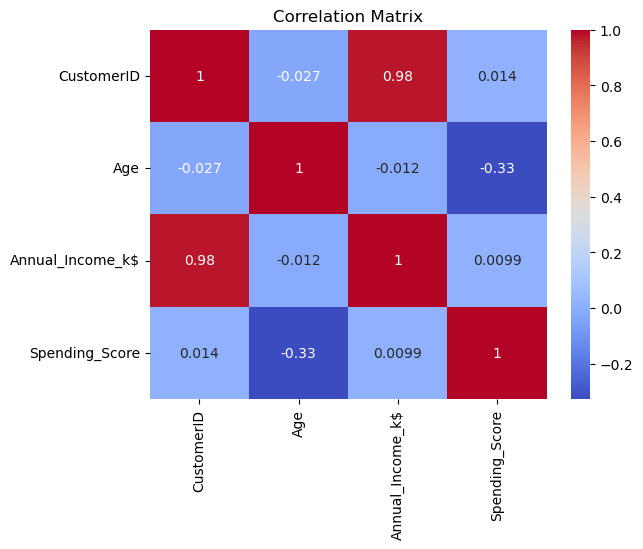

In [12]:
# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [43]:
# STEP 5: Features Encoding or preprocessing

# Drop ID column
df_cluster = df.drop('CustomerID', axis=1)

# One-hot encode categorical columns
categorical_cols = ['Gender', 'Education', 'Marital_Status']
df_cluster = pd.get_dummies(df_cluster, columns=categorical_cols, drop_first=True)

for col in df_cluster.columns:
 if df_cluster[col].dtype == 'bool':
  df_cluster[col] = df_cluster[col].astype(int)

# Select final features for clustering
features = df_cluster.columns
X = df_cluster.values

In [44]:
df_cluster.head()

,Age,Annual_Income_k$,Spending_Score,Cluster,Gender_M,Education_Doctorate,Education_Graduate,Education_High School,Education_Post-Graduate,Education_Uneducated,Education_Unknown,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown
0,19,15,39,2,1,0,0,1,0,0,0,1,0,0
1,21,15,81,2,1,0,1,0,0,0,0,0,1,0
2,20,16,6,0,0,0,1,0,0,0,0,1,0,0
3,23,16,77,2,0,0,0,1,0,0,0,0,0,1
4,31,17,40,0,0,0,0,0,0,1,0,1,0,0


<h2><b>Cluster Validation, K-Means Modelling and Cluster Visualization</b></h2>

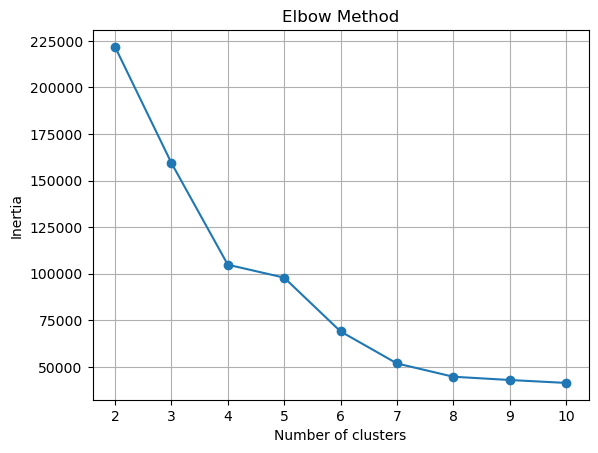

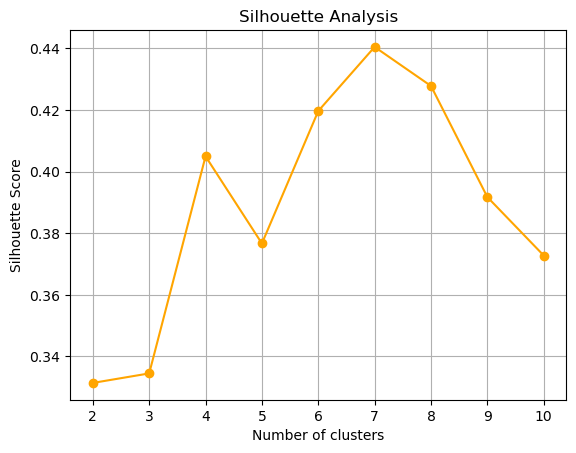

In [45]:
# STEP 6: Cluster Validation

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette = []
K_range = range(2, 11)  # cluster range

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X) 
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X, labels))

# Plot Elbow
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

# Plot Silhouette
plt.plot(K_range, silhouette, marker='o', color='orange')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.grid(True)
plt.show()

In [57]:
# STEP 7: K-Means Modelling 

from sklearn.cluster import KMeans

# Fit KMeans with your chosen number of clusters (example: 5)
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(X)  # or X_scaled if scaling used

# Add cluster labels to your DataFrame
df['Cluster'] = cluster_labels

<h2><b>PCA Plot</b></h2>

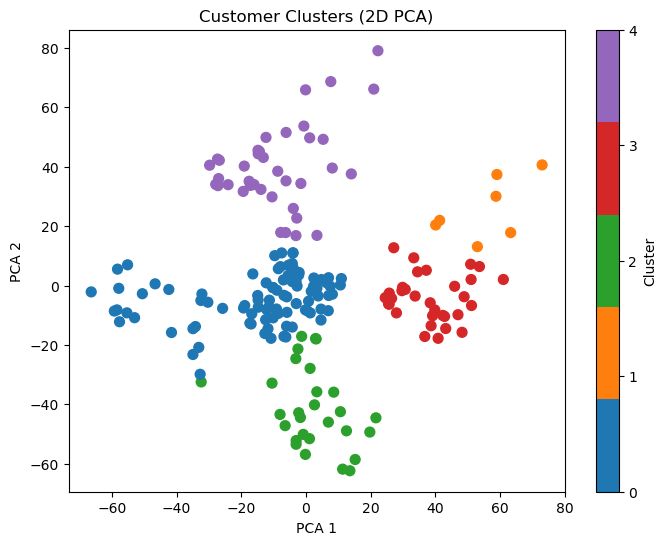

In [67]:
# STEP 8: PCA plot Cluster Visualization

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm  

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Only first 5 colors of tab10
cmap = ListedColormap(cm.get_cmap('tab10').colors[:5])

# Plot clusters with exact cluster numbers 0-4
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap=cmap, s=50)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Customer Clusters (2D PCA)')

# Colorbar with cluster numbers
cbar = plt.colorbar(scatter, ticks=[0,1,2,3,4])
cbar.set_label('Cluster')

plt.show()

In [25]:
print(df['Cluster'].value_counts())

Cluster
0    89
3    38
4    33
2    29
1    11
Name: count, dtype: int64


<h2><b>Final Conclusion</b></h2>

In [ ]:
Cluster Results (K-means on Age, Annual Income, Spending Score):  
- Cluster 0 – Luxury Shoppers: Young to middle-aged, high income, high spending score.  
- Cluster 1 – Budget-Conscious Seniors: Older, low income, low spending score.  
- Cluster 2 – Value Hunters: Young, low-to-mid income, high spending score.  
- Cluster 3 – Mid-Income Steady Buyers: Middle-aged, medium income, medium spending score.  
- Cluster 4 – High-Income Low Spenders: High income, low spending score.

Insights from Cluster Analysis:
Analysis of customer segmentation showed that the most influential factors in grouping were:  
- Annual income — clear separation between high and low earners.  
- Spending score — strongest driver for identifying high-value vs budget customers.  
- Age — revealed patterns in purchase behavior (younger customers spend more impulsively).  

# 🔍 Strategic Suggestions:

1. *Luxury Shoppers (Cluster 0) — Maintain loyalty via exclusive perks, early product access, and personalized luxury recommendations.  

2. *Budget-Conscious Seniors (Cluster 1)* — Promote affordable essentials, avoid aggressive upselling.  

3. *Value Hunters (Cluster 2)* — Use flash sales, discount coupons, and bundle promotions to drive engagement.  

4. *Mid-Income Steady Buyers (Cluster 3)* — Implement loyalty programs and seasonal offers to increase spending frequency.  

5. *High-Income Low Spenders (Cluster 4)* — Target with aspirational campaigns and premium upselling strategies.  

# Summary:  
K-means clustering reveals distinct customer segments that can be leveraged for precision marketing.  
By aligning marketing strategies to each group’s profile, businesses can increase revenue, improve customer satisfaction, and 
reduce wasted campaign costs.